In [1]:
import gensim.downloader as gensim_downloader
model = gensim_downloader.load("glove-wiki-gigaword-300")
embed_dim = 300

In [2]:
import torch
words = ["the", "cat", "sat", "on", "the", "mat"]
embeddings = torch.tensor([model.get_vector(w) for w in words])
# embeddings = embeddings / embeddings.norm(dim=1, keepdim=True)  # L2 normalize
embeddings.shape

/var/folders/qv/j5mf5zs97z9b52kbmsy4s8dm0000gn/T/ipykernel_94245/1174343695.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  embeddings = torch.tensor([model.get_vector(w) for w in words])


torch.Size([6, 300])

In [3]:
q = embeddings.unsqueeze(0)  # [1, seq_len, embed_dim]
k = embeddings.unsqueeze(0)
v = embeddings.unsqueeze(0)

In [5]:
from llm_from_scratch.attention.scaled_dot_product import scaled_dot_product_attention
_, attn_weights = scaled_dot_product_attention(q, k, v, causal=False, return_attn_weights=True)
attn_weights.shape

torch.Size([1, 6, 6])

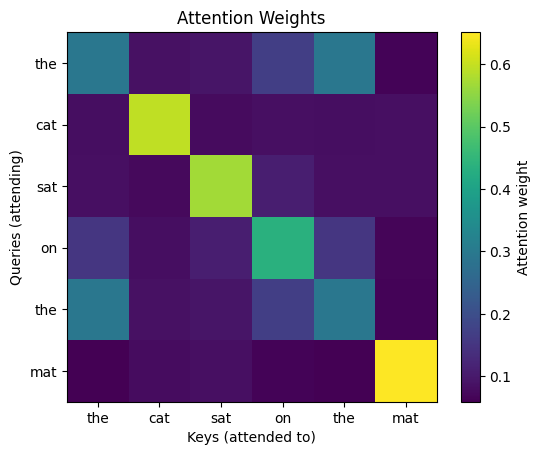

In [6]:
from matplotlib import pyplot as plt

plt.imshow(attn_weights[0].detach().numpy(), cmap='viridis')
plt.xticks(range(len(words)), words)
plt.yticks(range(len(words)), words)
plt.colorbar(label='Attention weight')
plt.xlabel('Keys (attended to)')
plt.ylabel('Queries (attending)')
plt.title('Attention Weights')
plt.show()